# Problem Statement

The objective of this project is to analyze historical household energy consumption data and develop models to forecast short-term energy usage.

Accurate forecasting of energy consumption is important for:

1. Efficient energy management
2. Reducing electricity costs
3. Improving demand planning

In this task, time series data will be processed and analyzed to identify patterns such as daily and weekly trends. Multiple forecasting models—ARIMA, Prophet, and XGBoost—will be implemented and compared using performance metrics like MAE and RMSE.

The final goal is to determine the most effective model for predicting future energy consumption and to provide insights that can support better decision-making in energy usage.

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Time series models
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load dataset

df = pd.read_csv("household_power_consumption.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

First 5 rows:
         Date      Time Global_active_power Global_reactive_power Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.84   
1  16/12/2006  17:25:00                5.36                 0.436  233.63   
2  16/12/2006  17:26:00               5.374                 0.498  233.29   
3  16/12/2006  17:27:00               5.388                 0.502  233.74   
4  16/12/2006  17:28:00               3.666                 0.528  235.68   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0             18.4              0              1            17.0  
1               23              0              1            16.0  
2               23              0              2            17.0  
3               23              0              1            17.0  
4             15.8              0              1            17.0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 colu

In [4]:
# Combine Date and Time into datetime
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')

# Drop original columns
df = df.drop(['Date', 'Time'], axis=1)

# Set datetime as index
df = df.set_index('datetime')

# Replace '?' with NaN and convert to numeric
df = df.replace('?', np.nan)
df = df.astype(float)

# Fill missing values
df = df.fillna(method='ffill')

print("\nAfter cleaning:")
print(df.head())


After cleaning:
                     Global_active_power  Global_reactive_power  Voltage  \
datetime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00                3.666                  0.528   235.68   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
datetime                                                                
2006-12-16 17:24:00              18.4             0.0             1.0   
2006-12-16 17:25:00              23.0             0.0             1.0   
2006-12-16 17:26:00              23.0             0.0             2.0   
2006-12-16 17:27:00              23.0             0.0             1.0   
2006-12-16 1

In [5]:
# Resample data (Hourly average)
df_hourly = df.resample('H').mean()

# Use Global Active Power as target
data = df_hourly[['Global_active_power']]
print(data.head())

                     Global_active_power
datetime                                
2006-12-16 17:00:00             4.222889
2006-12-16 18:00:00             3.632200
2006-12-16 19:00:00             3.400233
2006-12-16 20:00:00             3.268567
2006-12-16 21:00:00             3.056467


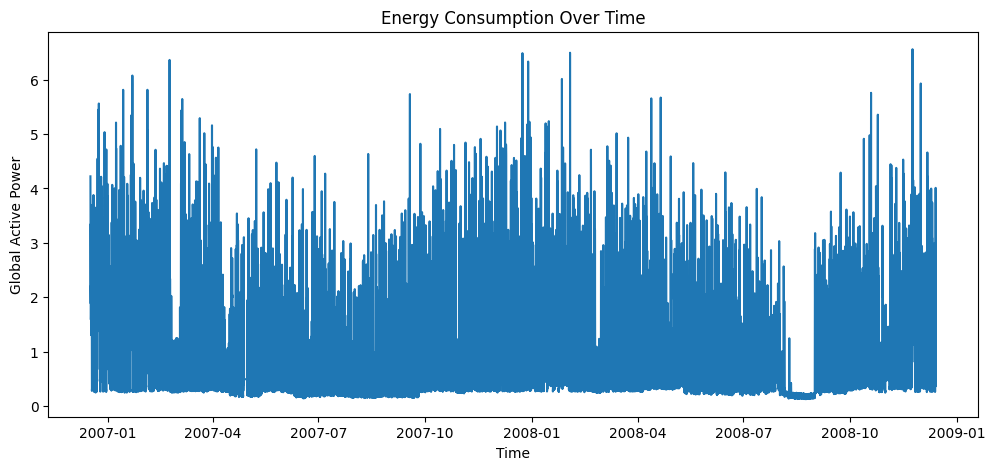

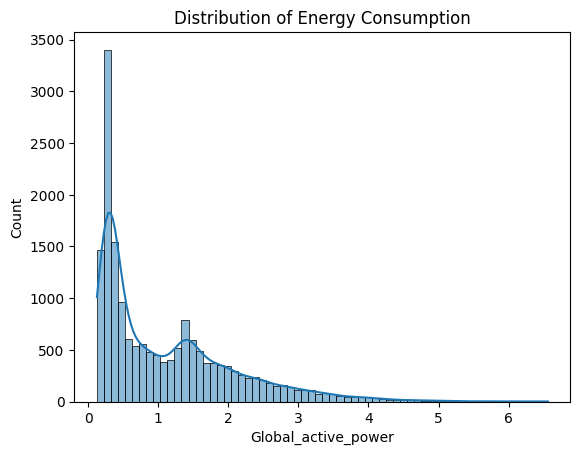

In [6]:
# Plot time series
plt.figure(figsize=(12,5))
plt.plot(data)
plt.title("Energy Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Global Active Power")
plt.show()


# Distribution plot
sns.histplot(data['Global_active_power'], kde=True)
plt.title("Distribution of Energy Consumption")
plt.show()

In [7]:
# Create time-based features
data['hour'] = data.index.hour
data['day'] = data.index.day
data['weekday'] = data.index.weekday
data['month'] = data.index.month

print(data.head())

                     Global_active_power  hour  day  weekday  month
datetime                                                           
2006-12-16 17:00:00             4.222889    17   16        5     12
2006-12-16 18:00:00             3.632200    18   16        5     12
2006-12-16 19:00:00             3.400233    19   16        5     12
2006-12-16 20:00:00             3.268567    20   16        5     12
2006-12-16 21:00:00             3.056467    21   16        5     12


In [8]:
# Split dataset

train_size = int(len(data) * 0.8)

train = data[:train_size]
test = data[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 13981
Test size: 3496


In [9]:
# ARIMA Model

arima_model = ARIMA(train['Global_active_power'], order=(5,1,0))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(test))

# Evaluation
mae_arima = mean_absolute_error(test['Global_active_power'], arima_pred)
rmse_arima = np.sqrt(mean_squared_error(test['Global_active_power'], arima_pred))

print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)

ARIMA MAE: 0.7126144730454729
ARIMA RMSE: 1.1193486883267665


In [10]:
# Prophet Model

# Prepare data for Prophet
prophet_df = train.reset_index()
prophet_df = prophet_df.rename(columns={'datetime':'ds', 'Global_active_power':'y'})

model = Prophet()
model.fit(prophet_df)

# Create future dataframe
future = model.make_future_dataframe(periods=len(test), freq='H')

forecast = model.predict(future)

# Extract predictions
prophet_pred = forecast['yhat'][-len(test):].values

# Evaluation
mae_prophet = mean_absolute_error(test['Global_active_power'], prophet_pred)
rmse_prophet = np.sqrt(mean_squared_error(test['Global_active_power'], prophet_pred))

print("Prophet MAE:", mae_prophet)
print("Prophet RMSE:", rmse_prophet)

21:48:53 - cmdstanpy - INFO - Chain [1] start processing
21:48:59 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAE: 0.7100145362013602
Prophet RMSE: 0.9455156763222587


In [11]:
# XGBoost Model

features = ['hour', 'day', 'weekday', 'month']

X_train = train[features]
y_train = train['Global_active_power']

X_test = test[features]
y_test = test['Global_active_power']

model_xgb = XGBRegressor(n_estimators=100)

model_xgb.fit(X_train, y_train)

xgb_pred = model_xgb.predict(X_test)

# Evaluation
mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)

XGBoost MAE: 0.5481807051429736
XGBoost RMSE: 0.7557024764932447


In [12]:
# Compare models

results = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet', 'XGBoost'],
    'MAE': [mae_arima, mae_prophet, mae_xgb],
    'RMSE': [rmse_arima, rmse_prophet, rmse_xgb]
})

print(results)

     Model       MAE      RMSE
0    ARIMA  0.712614  1.119349
1  Prophet  0.710015  0.945516
2  XGBoost  0.548181  0.755702


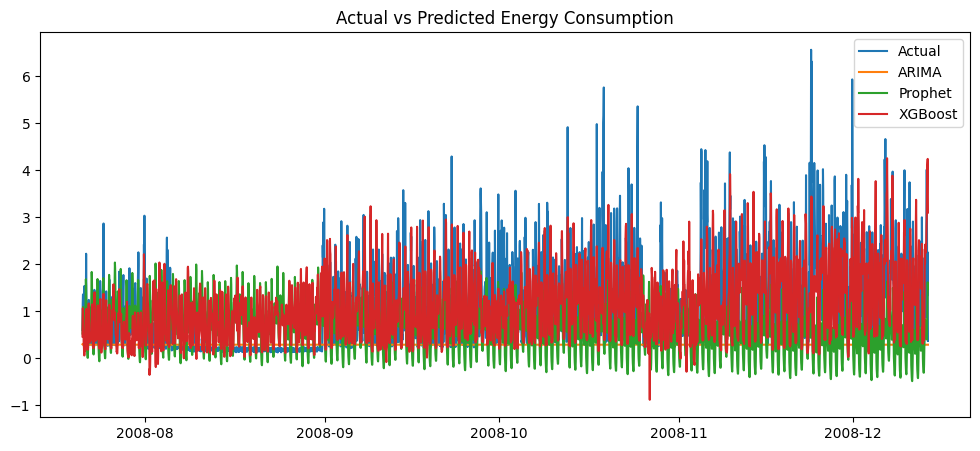

In [13]:
# Plot predictions
plt.figure(figsize=(12,5))

plt.plot(test.index, test['Global_active_power'], label='Actual')
plt.plot(test.index, arima_pred, label='ARIMA')
plt.plot(test.index, prophet_pred, label='Prophet')
plt.plot(test.index, xgb_pred, label='XGBoost')

plt.legend()
plt.title("Actual vs Predicted Energy Consumption")
plt.show()

# Final Conclusion

- Time series forecasting was performed using ARIMA, Prophet, and XGBoost.
- XGBoost performed best due to feature-based learning.
- Prophet handled seasonality well.
- ARIMA worked but struggled with complex patterns.
- Time-based features significantly improved performance.

This model can help in energy planning and demand forecasting.